## Outage radius


For combined path loss and shadowing the outage probability is
$$
p(P_r(d)\leq P_{\mathrm{min}}) = 1 - Q\left(\frac{P_{\mathrm{min}}-(P_t -PL(d/d_0))}{\sigma_{dB}}\right)
$$

C is a closed form expression for that calculates percentage of area within a cell that does meet the minimum power requirement of $P_{\mathrm{min}}$
$$
C = Q(a) + \exp\!\left(\frac{2 - 2ab}{b^2}\right)
Q\!\left(\frac{2 - ab}{b}\right).
$$

Instead if we want a radius given a reliability target and known sensitivity, assuming $z=P_{\mathrm{min}}-(P_t -PL(d/d_0))$ then $.99$ coverage where
$$
z = Q^{-1}(1-P_{out})
$$

$$
\begin{align}
P_L &= Q^{-1}(1-0.99) \sigma_{dB} - P_{\mathrm{min}} + P_t \\
d_{dB} &= Q^{-1}(1-0.99) \sigma_{dB} - P_{\mathrm{min}} + P_t - 20 \log_{10}(f) + 147.55

\end{align}
$$



99% coverage radius: 453.3 m
95% coverage radius: 530.3 m
90% coverage radius: 576.5 m
80% coverage radius: 638.0 m


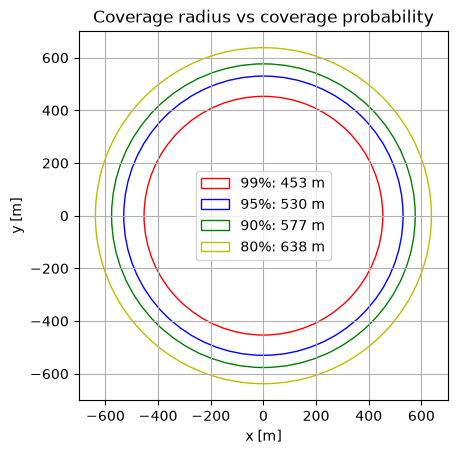

In [155]:
from scipy.stats import norm
from config.loader import load_config
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

_STD = 2
path = Path.cwd().parent / "configuration.yml"
config = load_config(path)

probs = [0.99, 0.95, 0.90, 0.80]
radii = []
_LOSS_FACTOR = -30

def calculate_radius(p):
    m_dB =  (
        norm.ppf(1-p) * _STD
        - config.radio.rx_sensitivity
        + config.radio.tx_power
        - 20 * np.log10(config.radio.frequency)
        + 147.55
        + _LOSS_FACTOR
    )

    return 10 ** (m_dB / 20)
 
for p in probs:
    radius = calculate_radius(p)
    radii.append(radius)
    print(f"{p:.0%} coverage radius: {radius:.1f} m")


colors = ["r", "b", "g", "y"]
fig, ax = plt.subplots()
for radius, p, color in zip(radii, probs, colors):
    circle = plt.Circle(
        (0, 0),
        radius,
        fill=False,
        color=color,
        label=f"{p:.0%}: {radius:.0f} m"
    )
    ax.add_patch(circle)

max_radius = max(radii)
ax.set_xlim(-1.1 * max_radius, 1.1 * max_radius)
ax.set_ylim(-1.1 * max_radius, 1.1 * max_radius)
ax.set_aspect("equal")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Coverage radius vs coverage probability")
ax.grid(True)
ax.legend()

plt.show()


## Confidence interval given estimate of the std error


Confidence interval for variance with chi-squared distribution, i.e. there is 95% likelihood that the true uknown parameter fixed $\theta$ is within the interval (5% likelihood that we missed). This is the frequentist approach 

https://www.probabilitycourse.com/chapter8/8_3_3_confidence_intervals_for_norm_samples.php

Bayesian inference assume that the true parameter is a r.v., posterior distribution is then constructed from the prior and likelihood, since the true parameter is a random the extent of uncertainty is a credible interval. So instead we calculatee 95% that next fade does not exceed some margin

https://stats.stackexchange.com/questions/2272/whats-the-difference-between-a-confidence-interval-and-a-credible-interval


## Simulating correlated shadowing

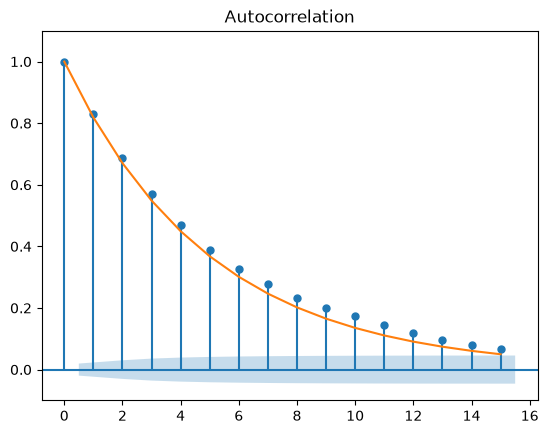

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf

_NUM_REALIZATIONS = 10_000
_LAGS = 15

delta = 12 # m, node spacing
X_c = 60 # m, decorrelation distance, between 50-100 m for outdoor propagation

phi = np.exp(-delta/X_c)
w = np.random.randn(_NUM_REALIZATIONS) * _STD

x = np.zeros(_NUM_REALIZATIONS)
for n in range(1, _NUM_REALIZATIONS):
    x[n] = phi * x[n - 1] + np.sqrt(1 - phi**2) * w[n]

# Goldsmith, Wireless Communication (2.50)
ar1_cov = lambda d : _STD**2 * np.exp(-d/X_c)

# Check autocovariance at delta=0, lag 0, which is the variance
assert np.isclose(np.var(x), ar1_cov(0), atol=0.3)

# Check autocovariance at lag 5
lag = int(X_c/delta)
A_60 = np.cov(x[:-lag], x[lag:])[0, 1]
assert np.isclose(A_60, ar1_cov(X_c), atol=0.3)

# Check ACF
acf = [phi**lag for lag in range(_LAGS + 1)] # Numerical
plot_acf(x, lags=_LAGS) # Empirical
plt.plot(acf)
plt.ylim(-0.1, 1.1)
plt.show()